## Define Paths and File Catalogue

In [10]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'
CSV_ROOT = PROJECT_ROOT / 'outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

print('Setup complete.')

Setup complete.


## Prepare data - sweep_r* folders

In [13]:
radii = [30, 60, 90, 150]

rows_r = []
for r in radii:
    print(f'  running r={r} …', end=' ', flush=True)

    outdir = OUTPUT_ROOT / f'sweep_r{r}'
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
        '--signal-col', SIGNAL_COL,
        '--spatial-radius', str(r),
        '--future-window-frames', '3',
        '--jump-quantile', '0.9',
        '--output-dir', str(outdir),
    ]
    subprocess.run(cmd, capture_output=True)
    sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
    if sp is None:
        sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
    with open(sp) as f:
        s = json.load(f)
    
    rows_r.append({
        'r': r,
        '|E_sp|': s['n_spatial_edges'],
        'θ': round(s['jump_threshold'], 4),
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
        'RD': round(s['risk_difference'], 4),
    })
    print('done')

df_r = pd.DataFrame(rows_r).set_index('r')
df_r

  running r=30 … done
  running r=60 … done
  running r=90 … done
  running r=150 … done


,|E_sp|,θ,p_exp,p_unexp,RR,RD
r,,,,,,
30,508839,0.0365,0.1797,0.0869,2.0680,0.0928
60,2389504,0.0365,0.1315,0.0749,1.7558,0.0566
90,5401402,0.0365,0.1120,0.0698,1.6051,0.0422
150,14339412,0.0365,0.0998,0.0751,1.3281,0.0247


## Load data

In [ ]:
import json
import pandas as pd
from pathlib import Path

# Find all radius sweep output folders
sweep_dirs = sorted(
    OUTPUT_ROOT.glob("sweep_r*")
)

results = []

for folder in sweep_dirs:

    # Path to summary statistics for a given radius
    summary_path = folder / f"exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}" / "summary.json"

    # Load summary file
    with open(summary_path) as f:
        summary = json.load(f)

    # Store radius and corresponding RR value
    results.append({
        "radius": summary["spatial_radius"],
        "RR": summary["relative_risk"]
    })

# Convert results into DataFrame
df_sweep = pd.DataFrame(results)

# Sort by radius value
df_sweep = df_sweep.sort_values("radius")

print(df_sweep)

   radius        RR
1    30.0  2.067998
2    60.0  1.755850
3    90.0  1.605140
0   150.0  1.328134


## Plot RR vs. parameter

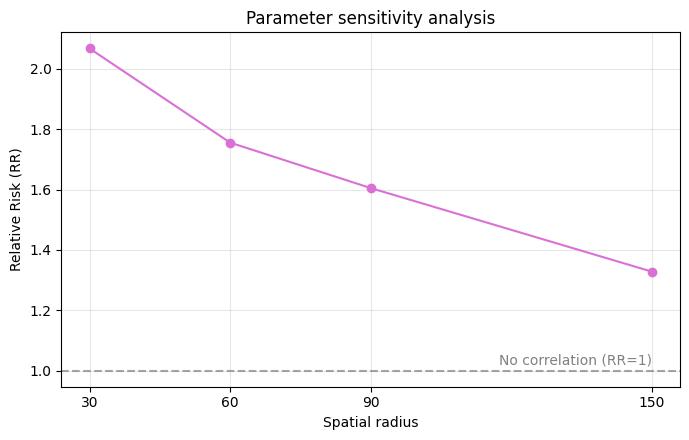

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))

# Main curve
plt.plot(
    df_sweep["radius"],
    df_sweep["RR"],
    marker='o',
    linestyle='-',
    color='orchid'
)

# Force all radius values to appear on x-axis
plt.xticks([30, 60, 90, 150])

# Reference line RR = 1
plt.axhline(
    y=1,
    linestyle='--',
    color='gray',
    alpha=0.7
)

# Label for reference line
plt.text(
    150,
    1.02,
    "No correlation (RR=1)",
    color='gray',
    ha='right'
)

plt.xlabel("Spatial radius")
plt.ylabel("Relative Risk (RR)")
plt.title("Parameter sensitivity analysis")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CSV_ROOT / "parameter_sensitivity_analysis_plot.png")
plt.show()